In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data").resolve()
assert data_dir.exists()

list(f"{pth.stem}{pth.suffix}" for pth in data_dir.glob("*"))


df = (
    pd.read_csv(
        data_dir / "co2_mlo_surface-insitu_1_ccgg_DailyData.csv",
        delim_whitespace=True,
        header=158,
    )
    .assign(date=lambda df: pd.to_datetime(df['datetime']))
    .drop(columns=["year", "month", "day", "hour", "minute", "second", "datetime", "time_decimal", "midpoint_time"]) # drop redundant cols
    # replace invalid values with NaN
    .assign(
        **{
            col: lambda df, col=col: df[col].where(df[col] >= 0) for col in ("value", "value_std_dev", "intake_height")
        }
    )
)

df

C:\Users\Max\AppData\Local\Temp\ipykernel_29280\3682534846.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(


,site_code,value,value_std_dev,nvalue,latitude,longitude,altitude,elevation,intake_height,qcflag,date
0,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,1974-01-01 00:00:00+00:00
1,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,1974-01-02 00:00:00+00:00
2,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,1974-01-03 00:00:00+00:00
3,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,1974-01-04 00:00:00+00:00
4,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,1974-01-05 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
18392,MLO,428.19,0.11,4,19.536,-155.576,3437.0,3397.0,40.0,...,2024-04-27 00:00:00+00:00
18393,MLO,NaN,NaN,0,19.536,-155.576,3387.1,3397.0,NaN,*..,2024-04-27 00:00:00+00:00
18394,MLO,427.44,0.40,12,19.536,-155.576,3437.0,3397.0,40.0,...,2024-04-28 00:00:00+00:00
18395,MLO,425.85,0.17,15,19.536,-155.576,3437.0,3397.0,40.0,...,2024-04-29 00:00:00+00:00


Text(0.5, 0, 'Date')

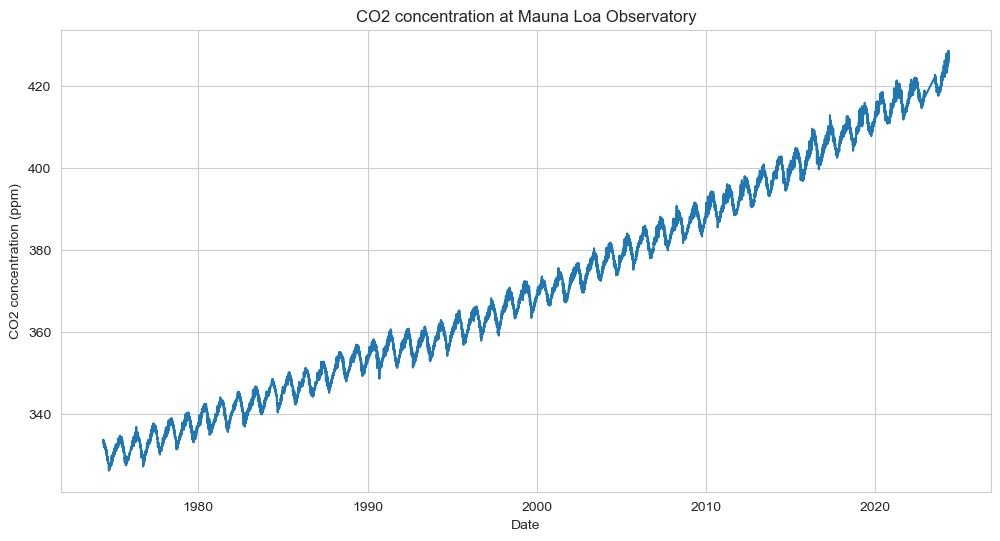

In [2]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="value")
plt.title("CO2 concentration at Mauna Loa Observatory")
plt.ylabel("CO2 concentration (ppm)")
plt.xlabel("Date")

In [3]:
from statsmodels.graphics.tsaplots import plot_acf
# group data to monthly
df.set_index("date", inplace=True)
df_monthly = df[["value"]].resample('M').mean()
df_yearly = df[["value"]].resample('Y').mean()
df_yearly.head(10)

C:\Users\Max\AppData\Local\Temp\ipykernel_29280\2413761695.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df[["value"]].resample('M').mean()
C:\Users\Max\AppData\Local\Temp\ipykernel_29280\2413761695.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df[["value"]].resample('Y').mean()


,value
date,
1974-12-31 00:00:00+00:00,329.567937
1975-12-31 00:00:00+00:00,331.403800
1976-12-31 00:00:00+00:00,332.013289
1977-12-31 00:00:00+00:00,333.861647
1978-12-31 00:00:00+00:00,335.460644
1979-12-31 00:00:00+00:00,336.761286
1980-12-31 00:00:00+00:00,338.809107
1981-12-31 00:00:00+00:00,340.146961
1982-12-31 00:00:00+00:00,341.369750


<Figure size 1200x600 with 0 Axes>

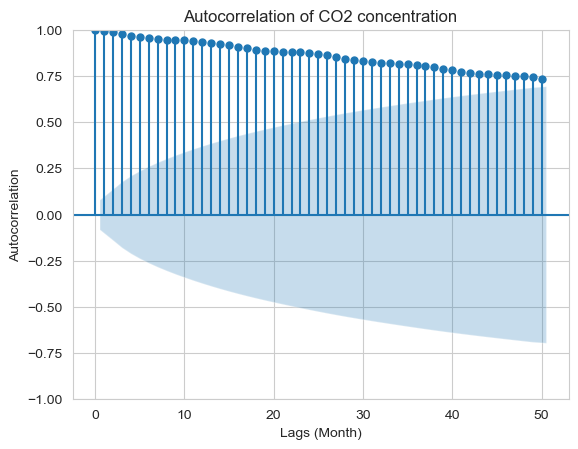

In [4]:
plt.figure(figsize=(12, 6))
plot_acf(df_monthly['value'].dropna(), lags=50)
plt.title("Autocorrelation of CO2 concentration")
plt.xlabel("Lags (Month)")
plt.ylabel("Autocorrelation")
plt.show()

<Figure size 1200x600 with 0 Axes>

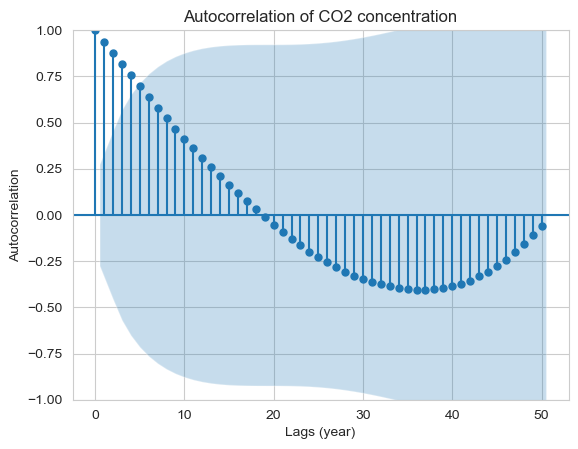

In [5]:
plt.figure(figsize=(12, 6))
plot_acf(df_yearly['value'].dropna(), lags=50)
plt.title("Autocorrelation of CO2 concentration")
plt.xlabel("Lags (year)")
plt.ylabel("Autocorrelation")
plt.show()

C:\Users\Max\AppData\Local\Temp\ipykernel_29280\169951209.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['value'].fillna(df['value'].mean(), inplace=True)


ValueError: cannot reindex on an axis with duplicate labels

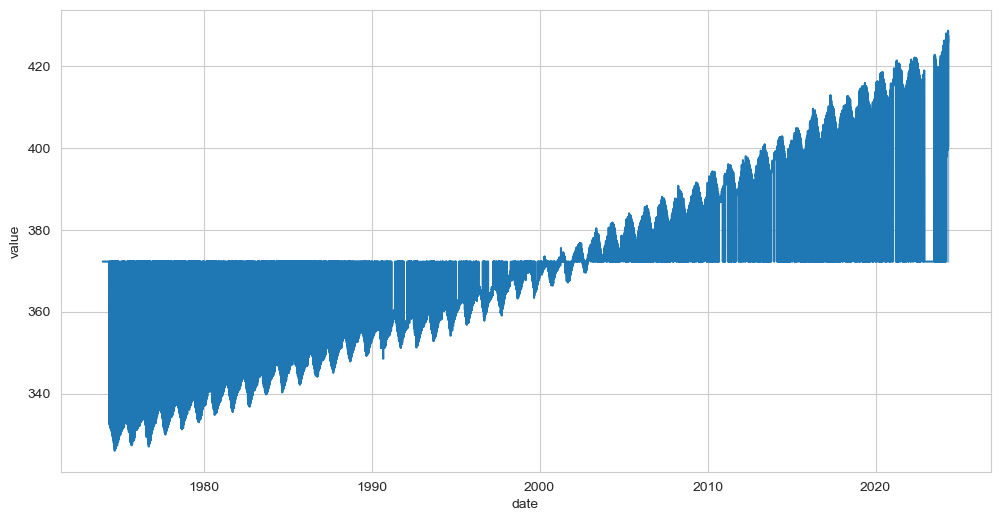

In [6]:
df['value'].fillna(df['value'].mean(), inplace=True)
df["value_trend"] = df["value"].rolling(365).mean()
df["value-trend"] = df["value"]-df["value_trend"]
plt.figure(figsize=(12, 6))
for col in ["value", "value-trend", "value_trend"]:
    sns.lineplot(data=df, x=df.index, y=col)
plt.title("CO2 concentration at Mauna Loa Observatory")
plt.ylabel("CO2 concentration (ppm)")
plt.xlabel("Date")